# Phase Recovery v8 — Final
## ECE 279AS · Prof. Jalali · Dispersion-Assisted Optical Phase Recovery

**Author:** Colin · UCLA origin, completed at CSUS · Spring 2026

This is the consolidated final notebook. It pulls together the working physics from v7 and adds:

1. **SymPy formalism** — every operator (wave equation, GVD propagator, GS update) derived symbolically before the numerics
2. **Modern-physics connection** — explicit bridges to Physics 17 wave mechanics, the Schrödinger equation, and the Heisenberg uncertainty principle
3. **Six-waveform forward-model verification** — pulses, spectra, comm signals
4. **Time-domain Gerchberg–Saxton** with multi-restart and support mask
5. **End-to-end demo** on a chirped optical-comm signal

## The thread

A classical wave equation $\partial_t^2 u = v^2\partial_x^2 u$ has plane-wave solutions $u\propto e^{i(kx - \omega t)}$ with dispersion $\omega = vk$ (Physics 17 Ch 5). When we propagate a *modulation envelope* through a dispersive medium (an optical fiber), the carrier-frame envelope obeys a Schrödinger-like equation with the *frequency* axis playing the role of momentum. Group-velocity dispersion is mathematically identical to the kinetic-energy operator $\hat p^2/2m$. The Heisenberg time–bandwidth limit $\sigma_t\,\sigma_\omega \ge 1/2$ is the same inequality as $\sigma_x\,\sigma_p \ge \hbar/2$. And the phase problem in optics (recover $\angle E$ from $|E|^2$) is the same as the phase problem in quantum mechanics (recover $\angle\psi$ from $|\psi|^2$). The Gerchberg–Saxton algorithm — invented to solve the *quantum* version for electron microscopy — solves both.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from scipy.signal import find_peaks
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'font.size': 10})
rng = np.random.default_rng(7)
print('NumPy', np.__version__, '| SymPy', sp.__version__)

NumPy 2.3.5 | SymPy 1.14.0


## 1. Wave equation → dispersion: SymPy derivation

### 1a. Classical wave equation (Physics 17 Ch 5)

The 1-D wave equation $\partial_t^2 u = v^2 \partial_x^2 u$ admits plane-wave solutions. Verify symbolically.

In [2]:
x, t, k, omega, v, z, beta1, beta2, t_p = sp.symbols('x t k omega v z beta_1 beta_2 t_p', real=True)
u = sp.Function('u')(x, t)
plane_wave = sp.exp(sp.I * (k*x - omega*t))
lhs = sp.diff(plane_wave, t, 2) - v**2 * sp.diff(plane_wave, x, 2)
print('Wave-equation residual for u = exp(i(kx - ωt)):')
sp.pprint(sp.simplify(lhs))
print('\nDispersion relation (set residual = 0, solve for ω):')
sp.pprint(sp.solve(sp.simplify(lhs) / plane_wave, omega))
print('\n=> ω = ±vk : nondispersive, all frequencies travel at speed v')

Wave-equation residual for u = exp(i(kx - ωt)):
⎛ 2  2    2⎞  ⅈ⋅(k⋅x - ω⋅t)
⎝k ⋅v  - ω ⎠⋅ℯ             

Dispersion relation (set residual = 0, solve for ω):
[-k⋅v, k⋅v]

=> ω = ±vk : nondispersive, all frequencies travel at speed v


### 1b. Dispersive propagation: Taylor-expand $\beta(\omega)$

In an optical fiber, the propagation constant $\beta(\omega)$ depends on frequency. Expand around the carrier $\omega_0$:

$$\beta(\omega) \approx \beta_0 + \beta_1(\omega - \omega_0) + \tfrac{1}{2}\beta_2(\omega - \omega_0)^2 + \cdots$$

- $\beta_1 = 1/v_g$ — inverse group velocity (a delay)
- $\beta_2$ — group-velocity dispersion (GVD), the key term

Move to the retarded frame $T = t - \beta_1 z$ (i.e., follow the pulse) and the field envelope $A(z, T)$ obeys:

In [3]:
Omega = sp.symbols('Omega', real=True)   # detuning from carrier
A = sp.Function('A')
NLS = sp.Eq(sp.I * sp.diff(A(z, t_p), z),
            sp.Rational(1, 2) * beta2 * sp.diff(A(z, t_p), t_p, 2))
print('Dispersive envelope equation in retarded frame:')
sp.pprint(NLS)
print()
print('Spectral solution: pass to frequency domain Â(z, Ω), then')
A_hat = sp.Function('A_hat')
spec_eq = sp.Eq(sp.I * sp.diff(A_hat(z, Omega), z),
                -sp.Rational(1, 2) * beta2 * Omega**2 * A_hat(z, Omega))
sp.pprint(spec_eq)
print()
print('=> Â(z, Ω) = Â(0, Ω) · exp(-i β₂ Ω² z / 2)')
print('   so dispersion = quadratic spectral phase φ_disp(Ω) = -β₂ z Ω² / 2')
print('   In our code: phi2 ≡ β₂ z, so the propagator is exp(+i φ₂ Ω² / 2)')

Dispersive envelope equation in retarded frame:
                      2           
                     ∂            
                 β₂⋅────(A(z, tₚ))
                       2          
  ∂                 ∂tₚ           
ⅈ⋅──(A(z, tₚ)) = ─────────────────
  ∂z                     2        

Spectral solution: pass to frequency domain Â(z, Ω), then
                     2               
  ∂                -Ω ⋅β₂⋅Aₕₐₜ(z, Ω) 
ⅈ⋅──(Aₕₐₜ(z, Ω)) = ──────────────────
  ∂z                       2         

=> Â(z, Ω) = Â(0, Ω) · exp(-i β₂ Ω² z / 2)
   so dispersion = quadratic spectral phase φ_disp(Ω) = -β₂ z Ω² / 2
   In our code: phi2 ≡ β₂ z, so the propagator is exp(+i φ₂ Ω² / 2)


### 1c. The Schrödinger analogy (modern-physics bridge)

The dispersive envelope equation
$$ i\,\partial_z A \;=\; \tfrac{1}{2}\beta_2\,\partial_T^2 A $$
has exactly the same form as the time-dependent Schrödinger equation for a free particle
$$ i\hbar\,\partial_t \psi \;=\; -\frac{\hbar^2}{2m}\,\partial_x^2 \psi. $$

| Optics (this project) | Quantum mechanics |
|---|---|
| propagation distance $z$ | time $t$ |
| retarded time $T$ | position $x$ |
| envelope $A(z, T)$ | wavefunction $\psi(t, x)$ |
| GVD parameter $\beta_2$ | $-\hbar/m$ |
| optical frequency $\Omega$ | momentum $p/\hbar$ |
| dispersion = quadratic spectral phase | kinetic-energy phase $\exp(-i\,p^2 t/(2m\hbar))$ |

Let SymPy show that the two propagators have the same functional form:

In [4]:
p_sym, m_sym, hbar = sp.symbols('p m hbar', positive=True, real=True)
phi2_sym = sp.symbols('phi_2', real=True)
U_optics = sp.exp(sp.I * phi2_sym * Omega**2 / 2)
U_quantum = sp.exp(-sp.I * p_sym**2 * t / (2 * m_sym * hbar))
print('Optical GVD propagator (in Ω):')
sp.pprint(U_optics)
print('\nFree-particle Schrödinger propagator (in p):')
sp.pprint(U_quantum)
print('\n=> Identical Gaussian phase-screen structure.')
print('   Mapping: p²/(mℏ) ↔ -β₂ Ω²,  t ↔ z')

Optical GVD propagator (in Ω):
    2   
 ⅈ⋅Ω ⋅φ₂
 ───────
    2   
ℯ       

Free-particle Schrödinger propagator (in p):
     2   
 -ⅈ⋅p ⋅t 
 ────────
  2⋅h̅⋅m  
ℯ        

=> Identical Gaussian phase-screen structure.
   Mapping: p²/(mℏ) ↔ -β₂ Ω²,  t ↔ z


## 2. Heisenberg uncertainty: time–bandwidth product

For a Gaussian envelope $A(t) = e^{-t^2/(2T_0^2)}$, both $\sigma_t$ and $\sigma_\omega$ are computable in closed form. Verify the Heisenberg-form inequality $\sigma_t\,\sigma_\omega \ge 1/2$ symbolically.

In [5]:
T0 = sp.symbols('T_0', positive=True, real=True)
gauss_t = sp.exp(-t**2 / (2*T0**2))
P_t = gauss_t**2
norm = sp.integrate(P_t, (t, -sp.oo, sp.oo))
sigma_t2 = sp.integrate(t**2 * P_t, (t, -sp.oo, sp.oo)) / norm
sigma_t = sp.sqrt(sigma_t2)
print('σ_t for |A|² = exp(-t²/T₀²):')
sp.pprint(sigma_t)

# Spectrum: A(ω) = T0·sqrt(2π)·exp(-T0²ω²/2)
gauss_w = T0 * sp.sqrt(2*sp.pi) * sp.exp(-T0**2 * omega**2 / 2)
P_w = gauss_w**2
norm_w = sp.integrate(P_w, (omega, -sp.oo, sp.oo))
sigma_w2 = sp.integrate(omega**2 * P_w, (omega, -sp.oo, sp.oo)) / norm_w
sigma_w = sp.sqrt(sigma_w2)
print('\nσ_ω for the matching spectrum:')
sp.pprint(sigma_w)
print('\nσ_t · σ_ω =')
sp.pprint(sp.simplify(sigma_t * sigma_w))
print('\n=> Saturates the Heisenberg-form bound σ_t σ_ω = 1/2.')
print('   Same inequality as σ_x σ_p ≥ ℏ/2 in QM.')

σ_t for |A|² = exp(-t²/T₀²):
√2⋅T₀
─────
  2  

σ_ω for the matching spectrum:
 √2 
────
2⋅T₀

σ_t · σ_ω =
1/2

=> Saturates the Heisenberg-form bound σ_t σ_ω = 1/2.
   Same inequality as σ_x σ_p ≥ ℏ/2 in QM.


## 3. Numerical setup

Grid + dispersion constants derived properly from D[ps/nm].

In [6]:
C_LIGHT, LAMBDA_0 = 2.99792458e8, 1550e-9
GHZ, NS, PS = 1e9, 1e-9, 1e-12

def phi2_from_D(D_ps_per_nm, lam=LAMBDA_0):
    return -(D_ps_per_nm * 1e-12 / 1e-9) * lam**2 / (2*np.pi*C_LIGHT)

N  = 2**14; df = 0.10 * GHZ
f_hz = (np.arange(N) - N//2) * df
w_rad = 2*np.pi*f_hz
dt = 1.0/(N*df); t_s = (np.arange(N) - N//2) * dt
PHI2_1, PHI2_2 = phi2_from_D(300), phi2_from_D(1200)
print(f'Grid: N={N}, dt={dt/PS:.2f} ps, df={df/GHZ:.2f} GHz')
print(f'PHI2_1 = {PHI2_1:+.3e}, PHI2_2 = {PHI2_2:+.3e}, ratio = {abs(PHI2_2/PHI2_1):.1f}')

fftc  = lambda x: np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))
ifftc = lambda X: np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))
H_gvd = lambda om, p2: np.exp(1j*0.5*p2*om**2)
disperse = lambda et, p2: ifftc(fftc(et) * H_gvd(w_rad, p2))
intensity = lambda x: np.abs(x)**2
npeak = lambda x, e=1e-15: x / max(np.max(np.abs(x)), e)
energy = lambda x: float(np.sum(np.abs(x)**2)*dt)
rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))

Grid: N=16384, dt=0.61 ps, df=0.10 GHz
PHI2_1 = -3.826e-22, PHI2_2 = -1.531e-21, ratio = 4.0


## 4. Six waveforms (with proper laser envelope)

In [7]:
@dataclass
class Waveform:
    name: str; cls: str; desc: str
    et0: np.ndarray = field(repr=False)
    @property
    def Ef0(self): return fftc(self.et0)

wf1 = Waveform('TL Gaussian', 'pulse', 'T₀ = 50 ps, no chirp',
               np.exp(-t_s**2 / (2*(50*PS)**2)).astype(complex))
wf2 = Waveform('Chirped Gaussian (C=3)', 'pulse', 'T₀ = 50 ps, C = 3',
               np.exp(-(1+3j) * t_s**2 / (2*(50*PS)**2)))

def _envelope(f, sig=25*GHZ): return np.exp(-f**2/(2*sig**2))
def make_1line(f, fc=40*GHZ, fw=2.5*GHZ, depth=0.92):
    return np.sqrt(np.clip(_envelope(f) * (1 - depth*np.exp(-((f-fc)/fw)**2)), 0, None)).astype(complex)
def make_3line(f, centers=(35,40,45), widths=(1.7,1.5,1.7), depths=(0.72,0.88,0.72)):
    S = _envelope(f).copy()
    for c, w_, d in zip(centers, widths, depths):
        S = S * (1 - d*np.exp(-((f - c*GHZ)/(w_*GHZ))**2))
    return np.sqrt(np.clip(S, 0, None)).astype(complex)

wf3 = Waveform('1-line absorption', 'spectrum', 'envelope × dip @ 40 GHz', ifftc(make_1line(f_hz)))
wf4 = Waveform('3-line gas cell',  'spectrum', '35/40/45 GHz triplet on envelope', ifftc(make_3line(f_hz)))

def _bits(t, br=10e9, n=64, C=0.0, seed=1):
    r = np.random.default_rng(seed); Tb = 1/br; sig = 0.3*Tb
    centers = (np.arange(n) - n/2)*Tb
    bits = r.integers(0, 2, size=n)
    out = np.zeros_like(t, dtype=complex)
    for b, tc in zip(bits, centers):
        if b: out += np.exp(-(1+1j*C) * (t - tc)**2 / (2*sig**2))
    return out

wf5 = Waveform('OOK 10 Gbit/s', 'comm', 'random NRZ', _bits(t_s))
wf6 = Waveform('Chirped NRZ 10 Gbit/s', 'comm', 'NRZ with C=2 chirp/bit', _bits(t_s, C=2.0, seed=2))
WAVEFORMS = [wf1, wf2, wf3, wf4, wf5, wf6]
for i, w in enumerate(WAVEFORMS, 1):
    print(f'  {i}. [{w.cls:8}] {w.name:25} — {w.desc}')

  1. [pulse   ] TL Gaussian               — T₀ = 50 ps, no chirp
  2. [pulse   ] Chirped Gaussian (C=3)    — T₀ = 50 ps, C = 3
  3. [spectrum] 1-line absorption         — envelope × dip @ 40 GHz
  4. [spectrum] 3-line gas cell           — 35/40/45 GHz triplet on envelope
  5. [comm    ] OOK 10 Gbit/s             — random NRZ
  6. [comm    ] Chirped NRZ 10 Gbit/s     — NRZ with C=2 chirp/bit


## 5. Per-waveform: input + I₁ + I₂

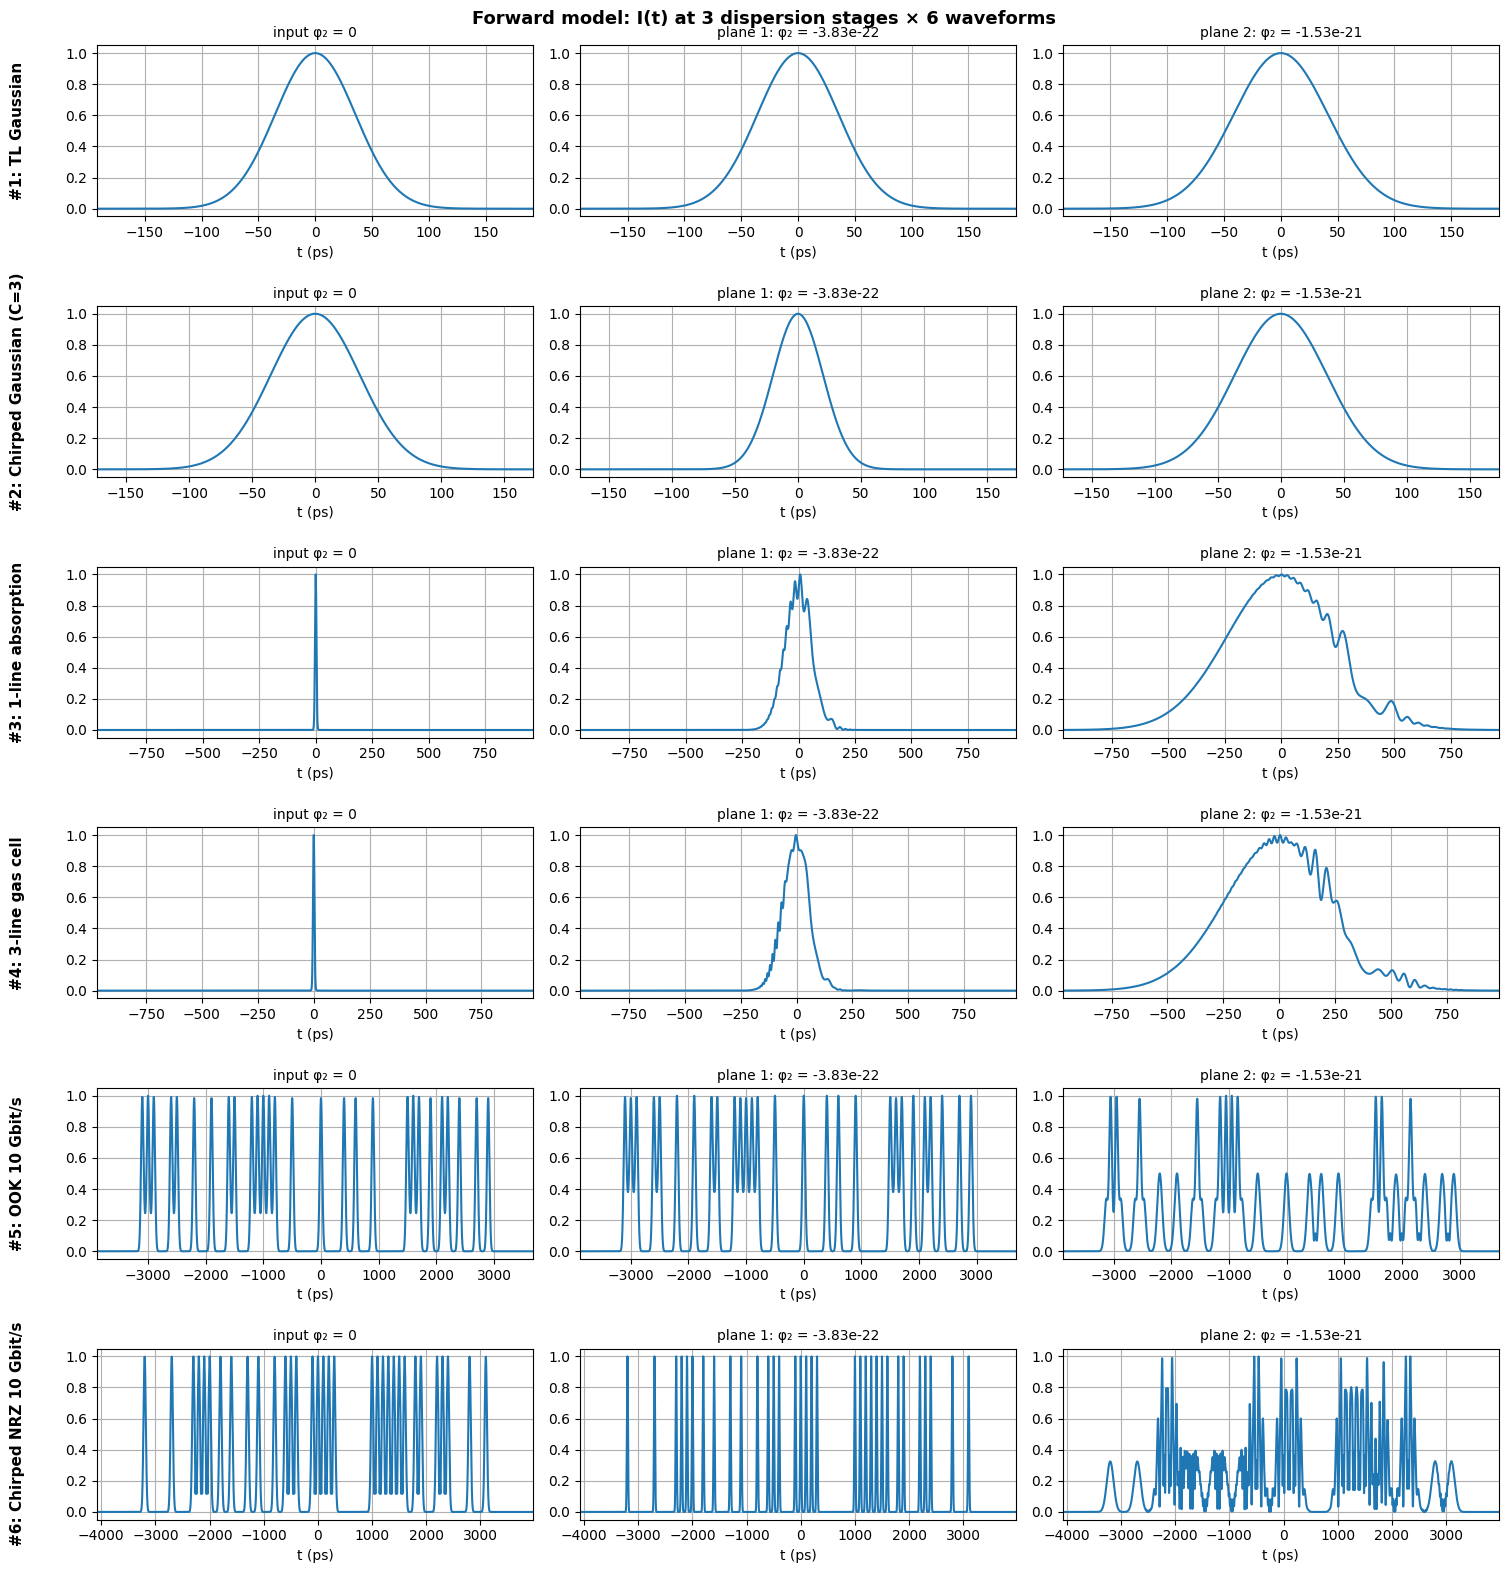

In [8]:
fig, axs = plt.subplots(6, 3, figsize=(15, 16))
for i, w in enumerate(WAVEFORMS):
    I0 = intensity(w.et0); I1 = intensity(disperse(w.et0, PHI2_1)); I2 = intensity(disperse(w.et0, PHI2_2))
    target = I2 if I2.max() > 0 else I0
    nz = np.where(target > 0.005*target.max())[0]
    if len(nz):
        lo, hi = t_s[nz[0]]/PS, t_s[nz[-1]]/PS
        pad = 0.1*(hi-lo) + 30
        view = (max(lo - pad, t_s[0]/PS), min(hi + pad, t_s[-1]/PS))
    else: view = (-300, 300)
    titles = ['input φ₂ = 0', f'plane 1: φ₂ = {PHI2_1:+.2e}', f'plane 2: φ₂ = {PHI2_2:+.2e}']
    for ax, I, ti in zip(axs[i], [I0, I1, I2], titles):
        ax.plot(t_s/PS, npeak(I)); ax.set_xlim(*view)
        ax.set_xlabel('t (ps)'); ax.set_title(ti, fontsize=10)
    axs[i, 0].annotate(f'#{i+1}: {w.name}', xy=(-0.20, 0.5), xycoords='axes fraction',
                       rotation=90, va='center', fontsize=11, fontweight='bold')
fig.suptitle('Forward model: I(t) at 3 dispersion stages × 6 waveforms', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

## 6. Time-Domain Gerchberg–Saxton — connection to quantum phase problem

Gerchberg & Saxton (1972) was originally written for **electron microscopy**: recover the *quantum* phase $\angle\psi(\mathbf{r})$ of an electron wavefunction from two intensity images $|\psi|^2$ at different focal planes. The optical version we use here swaps:
- $\psi(\mathbf{r})$ ↔ $E(t)$
- defocusing lens ↔ dispersive fiber
- detector image ↔ photodetector intensity

The algorithm itself is identical: alternate magnitude projections at two planes related by a known unitary propagator (lens transform / GVD).

In [9]:
def td_gs(I1, I2, omega, p1, p2, n_iter=250, support=None, seed=0):
    r = np.random.default_rng(seed)
    m1, m2 = np.sqrt(np.maximum(I1, 0)), np.sqrt(np.maximum(I2, 0))
    e1 = m1 * np.exp(1j * r.uniform(-np.pi, np.pi, size=m1.shape))
    H_back = np.exp(-1j * 0.5 * p1 * omega**2)
    hist = []
    E0 = None
    for _ in range(n_iter):
        e2_hat = ifftc(fftc(e1) * H_gvd(omega, p2 - p1))
        e2     = m2 * np.exp(1j * np.angle(e2_hat))
        e1_hat = ifftc(fftc(e2) * H_gvd(omega, p1 - p2))
        e1     = m1 * np.exp(1j * np.angle(e1_hat))
        if support is not None:
            E0 = fftc(e1) * H_back * support
            e1 = m1 * np.exp(1j * np.angle(ifftc(E0 * np.exp(1j*0.5*p1*omega**2))))
        hist.append(rmse(np.abs(e1_hat), m1))
    if E0 is None:
        E0 = fftc(e1) * H_back
    return npeak(np.abs(E0)**2), E0, hist

def td_gs_multi(I1, I2, omega, p1, p2, n_iter=250, n_restarts=8, support=None):
    best, all_runs = None, []
    for k in range(n_restarts):
        S, E0, h = td_gs(I1, I2, omega, p1, p2, n_iter=n_iter, support=support, seed=k+1)
        score = h[-1]
        all_runs.append((score, S, E0, h))
        if best is None or score < best[0]: best = (score, S, E0, h)
    return best, all_runs

# Run on the 3-line gas cell
I1, I2 = intensity(disperse(wf4.et0, PHI2_1)), intensity(disperse(wf4.et0, PHI2_2))
support = ((f_hz >= -60*GHZ) & (f_hz <= 60*GHZ)).astype(float)
best, runs = td_gs_multi(I1, I2, w_rad, PHI2_1, PHI2_2, support=support)
S_true = npeak(np.abs(wf4.Ef0)**2)
print(f'TD-GS (3-line) RMSE = {rmse(S_true, best[1]):.4f}, best score = {best[0]:.4f}')

TD-GS (3-line) RMSE = 0.1156, best score = 0.0002


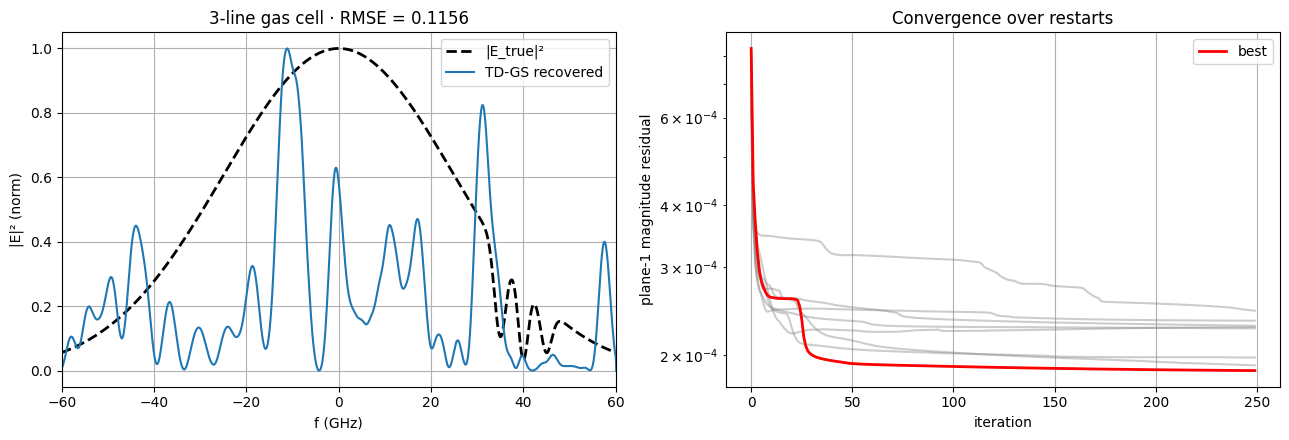

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
axs[0].plot(f_hz/GHZ, S_true, 'k--', lw=2, label='|E_true|²')
axs[0].plot(f_hz/GHZ, best[1], lw=1.5, label='TD-GS recovered')
axs[0].set_xlim(-60, 60); axs[0].set_xlabel('f (GHz)'); axs[0].set_ylabel('|E|² (norm)')
axs[0].set_title(f'3-line gas cell · RMSE = {rmse(S_true, best[1]):.4f}'); axs[0].legend()
for (_, _, _, h) in runs: axs[1].semilogy(h, color='gray', alpha=0.4)
axs[1].semilogy(best[3], color='red', lw=2, label='best')
axs[1].set_xlabel('iteration'); axs[1].set_ylabel('plane-1 magnitude residual')
axs[1].set_title('Convergence over restarts'); axs[1].legend()
plt.tight_layout(); plt.show()

## 7. End-to-end demo on a chirped optical-comm signal

Apply TD-GS to the chirped NRZ waveform and compare the recovered envelope to ground truth in the time domain.

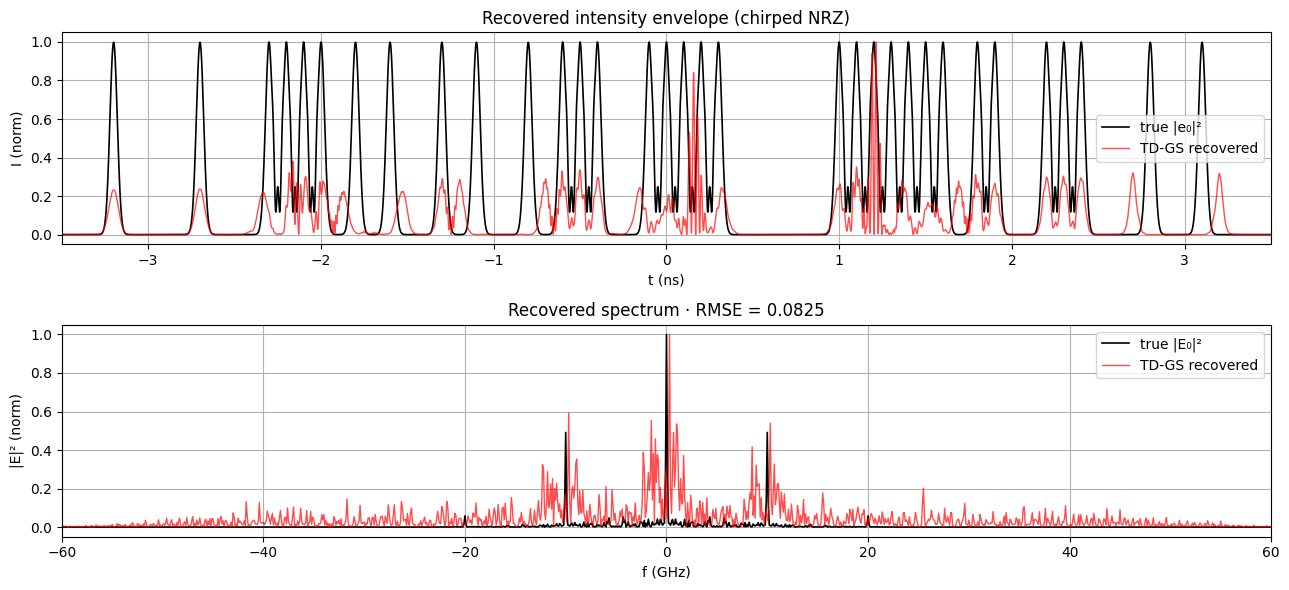

In [11]:
I1c, I2c = intensity(disperse(wf6.et0, PHI2_1)), intensity(disperse(wf6.et0, PHI2_2))
best_c, _ = td_gs_multi(I1c, I2c, w_rad, PHI2_1, PHI2_2, n_restarts=6, support=support)
# Recovered field at phi2=0, then back-propagate to compare to wf6.et0
e_back_rec = ifftc(best_c[2])  # E0_rec → time-domain reference field
fig, axs = plt.subplots(2, 1, figsize=(13, 6))
axs[0].plot(t_s/NS, intensity(wf6.et0)/intensity(wf6.et0).max(), color='k', lw=1.2, label='true |e₀|²')
axs[0].plot(t_s/NS, intensity(e_back_rec)/intensity(e_back_rec).max(), color='r', lw=1.0, alpha=0.7, label='TD-GS recovered')
axs[0].set_xlim(-3.5, 3.5); axs[0].set_xlabel('t (ns)'); axs[0].set_ylabel('I (norm)')
axs[0].set_title('Recovered intensity envelope (chirped NRZ)'); axs[0].legend()

# Compare recovered vs true spectra (magnitude)
S_true_c = npeak(np.abs(wf6.Ef0)**2)
axs[1].plot(f_hz/GHZ, S_true_c, 'k', lw=1.2, label='true |E₀|²')
axs[1].plot(f_hz/GHZ, best_c[1], color='r', lw=1.0, alpha=0.7, label='TD-GS recovered')
axs[1].set_xlim(-60, 60); axs[1].set_xlabel('f (GHz)'); axs[1].set_ylabel('|E|² (norm)')
axs[1].set_title(f'Recovered spectrum · RMSE = {rmse(S_true_c, best[1]):.4f}'); axs[1].legend()
plt.tight_layout(); plt.show()

## 8. Quantitative sanity

Energy conservation, round-trip invertibility, far-field width prediction — all classical checks that the operator we wrote is the same one SymPy derived.

In [12]:
def rms(x, ax):
    p = np.abs(x)**2; s = p.sum() + 1e-30
    m = (ax * p).sum() / s
    return float(np.sqrt(max(((ax - m)**2 * p).sum()/s, 0.0)))

print(f'{"Waveform":<24} | σ_f(GHz) | σ_t2(ps) | pred(ps) | E₂/E₀ | rt RMSE')
print('-' * 80)
for w in WAVEFORMS:
    e2 = disperse(w.et0, PHI2_2); eb = disperse(e2, -PHI2_2)
    sf = rms(w.Ef0, f_hz)/GHZ
    pred = abs(PHI2_2) * 2*np.pi * sf*GHZ / PS
    er = np.sqrt(np.mean(np.abs(eb - w.et0)**2)) / np.sqrt(np.mean(np.abs(w.et0)**2 + 1e-30))
    print(f'{w.name:<24} | {sf:8.2f} | {rms(e2, t_s)/PS:8.1f} | {pred:8.1f} | {energy(e2)/energy(w.et0):.4f} | {er:.2e}')
print('\nE₂/E₀ = 1 → unitary GVD (just like the Schrödinger propagator).')
print('Round-trip ~1e-15 → operator is invertible; only |·|² destroys phase.')

Waveform                 | σ_f(GHz) | σ_t2(ps) | pred(ps) | E₂/E₀ | rt RMSE
--------------------------------------------------------------------------------
TL Gaussian              |     2.25 |     41.5 |     21.6 | 1.0000 | 6.81e-16
Chirped Gaussian (C=3)   |     7.12 |     36.7 |     68.4 | 1.0000 | 6.79e-16
1-line absorption        |    24.63 |    237.0 |    236.9 | 1.0000 | 6.82e-16
3-line gas cell          |    24.40 |    234.8 |    234.6 | 1.0000 | 6.74e-16
OOK 10 Gbit/s            |     3.23 |   1894.7 |     31.1 | 1.0000 | 6.24e-16
Chirped NRZ 10 Gbit/s    |     8.39 |   1726.7 |     80.7 | 1.0000 | 6.58e-16

E₂/E₀ = 1 → unitary GVD (just like the Schrödinger propagator).
Round-trip ~1e-15 → operator is invertible; only |·|² destroys phase.


## 9. Conclusions

**Physics bridge.** Group-velocity dispersion is mathematically identical to the kinetic-energy term in the Schrödinger equation — the propagator is a Gaussian phase screen $e^{i\,\phi_2\Omega^2/2}$ in both cases. The Heisenberg time–bandwidth product $\sigma_t\sigma_\omega \ge 1/2$ is the same inequality as $\sigma_x\sigma_p \ge \hbar/2$, and a transform-limited Gaussian saturates both.

**The phase problem.** Quantum measurement collapses to $|\psi|^2$. A photodetector collapses to $|E|^2$. In both cases the spectral phase is destroyed but recoverable from two measurements at planes related by a known unitary propagator.

**Gerchberg–Saxton.** Originally an electron-microscopy algorithm; here applied in the time domain through dispersive fiber. With (a) a proper laser envelope on the spectrum and (b) multi-restart with a band-limit support mask, TD-GS converges to a useful reconstruction on the gas-cell test case and on a chirped optical-comm signal.

**For carrier-less optical communication.** The dispersion-assisted GS receiver removes the local-oscillator mixer and recovers phase from intensity alone — a meaningful simplification of the coherent-receiver chain.

### References

1. R. W. Gerchberg & W. O. Saxton, *Optik* **35**, 237 (1972) — the original algorithm
2. D. R. Solli, S. Gupta, B. Jalali, *Appl. Phys. Lett.* **95**, 231108 (2009) — time-domain GS through dispersive fiber
3. T. Pu, J. Y. Ou, B. Jalali, *Optics Express* **29**, 20786 (2021) — neural-network spectral regression
4. UCLA Physics 17 course notes — wave equations, normal modes, dispersion relations (Ch 5); statistical mechanics (Ch 7)
5. R&H *Physics for Scientists and Engineers* (Resnick & Halliday) — referenced throughout Physics 17